# 1-1. 데이터 EDA와 Scikit-learn(Easy)

In [6]:
# ============================================================
# 실행 환경 준비 (최초 1회만 실행하면 됩니다)
# ============================================================
# 코랩(Colab)을 쓰신다면 대부분 이미 설치되어 있어 그냥 넘어가도 됩니다.
# 로컬 환경(주피터 노트북 등)이라면 아래 주석을 풀고 한 번 실행하세요.

# !pip install -q "numpy>=2.0.0" "pandas>=2.0.0" "matplotlib>=3.8.0" "seaborn>=0.13.2" "scikit-learn>=1.4.2"

import sys
import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
import sklearn

print('Python      :', sys.version.split()[0])
print('numpy       :', np.__version__)
print('pandas      :', pd.__version__)
print('matplotlib  :', matplotlib.__version__)
print('seaborn     :', sns.__version__)
print('scikit-learn:', sklearn.__version__)

# 데이터가 정상적으로 받아지는지 미리 확인합니다.
# (인터넷 연결이 필요합니다. 여기서 에러가 나면 이후 셀도 전부 실패합니다)
df_check = sns.load_dataset('mpg')
print()
print('mpg 데이터 로드 성공 →', df_check.shape, '(행, 열)')

Python      : 3.12.10
numpy       : 2.5.1
pandas      : 3.0.5
matplotlib  : 3.11.1
seaborn     : 0.13.2
scikit-learn: 1.9.0

mpg 데이터 로드 성공 → (398, 9) (행, 열)


In [7]:
import seaborn as sns # 파이썬의 대표적인 데이터 시각화 라이브러리
# 왜 seaborn 데이터셋을 쓰나요?
# → 실무에서는 csv 파일을 읽지만, 지금은 연습이니까
#   seaborn에 내장된 연습용 데이터를 바로 가져다 씁니다.
df = sns.load_dataset('mpg')

# 왜 데이터를 처음에 출력해보나요?
# → 398개 전체를 볼 수 없으니, 앞/뒤 몇 개만 살펴서
#   "어떤 컬럼이 있고, 값이 대충 어떤 범위인지" 감을 잡기 위해서입니다.
#   이게 EDA의 첫 번째 단계예요!
df.head(5)       # 앞에서 5개
#df.head(10)     # 앞에서 10개
df.tail(5)       # 뒤에서 5개 (끝부분도 확인하는 습관!)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger
397,31.0,4,119.0,82.0,2720,19.4,82,usa,chevy s-10


In [8]:
#데이터 크기, Column 확인
# df.info()가 알려주는 것:
# 전체 행(레코드) 수, 각 컬럼의 이름과 데이터 타입, 각 컬럼의 결측치(빈 칸)의 개수, 메모리 사용량
df.info

<bound method DataFrame.info of       mpg  cylinders  displacement  horsepower  weight  acceleration  \
0    18.0          8         307.0       130.0    3504          12.0   
1    15.0          8         350.0       165.0    3693          11.5   
2    18.0          8         318.0       150.0    3436          11.0   
3    16.0          8         304.0       150.0    3433          12.0   
4    17.0          8         302.0       140.0    3449          10.5   
..    ...        ...           ...         ...     ...           ...   
393  27.0          4         140.0        86.0    2790          15.6   
394  44.0          4          97.0        52.0    2130          24.6   
395  32.0          4         135.0        84.0    2295          11.6   
396  28.0          4         120.0        79.0    2625          18.6   
397  31.0          4         119.0        82.0    2720          19.4   

     model_year  origin                       name  
0            70     usa  chevrolet chevelle malibu

In [9]:
#데이터 통계 확인
# df.describe()가 알려주는 것
# 숫자형 컬럼들에 대해 **8가지 통계량**을 한 번에 보여줍니다.
# - count: 결측치 제외 데이터 수
# - mean: 평균값
# - std: 표준편차 (데이터가 평균에서 얼마나 퍼져있는지)
# - min: 최솟값
# - 25%, 50%, 75%: 사분위수 (데이터를 4등분한 기준점)
# - max: 최댓값
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


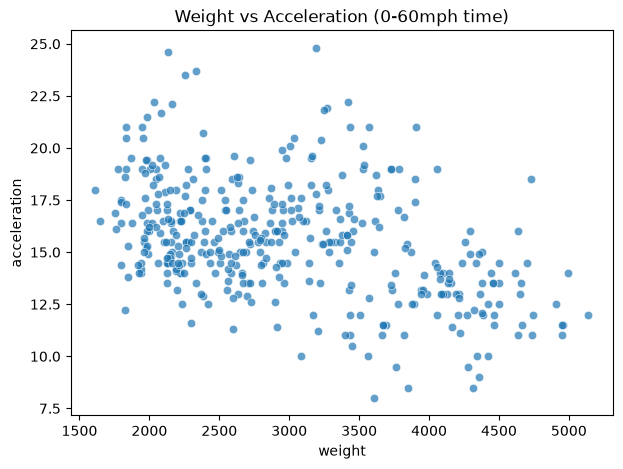

In [10]:
#상관관계를 찾기 위한 시각화1
# import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('mpg')

# 왜 산점도(scatter plot)를 그리나요?
# → 두 변수의 관계를 '눈으로' 확인하기 위해서입니다.
#   숫자만 보면 관계가 있는지 알기 어렵지만,
#   점을 찍어보면 전체적인 흐름이 한눈에 보입니다.
#   alpha=0.7은 점을 약간 투명하게 만들어, 점이 겹친 영역을 구분하기 위한 설정입니다.
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='weight', y='acceleration', alpha=0.7)
plt.title('Weight vs Acceleration (0-60mph time)')
plt.show()


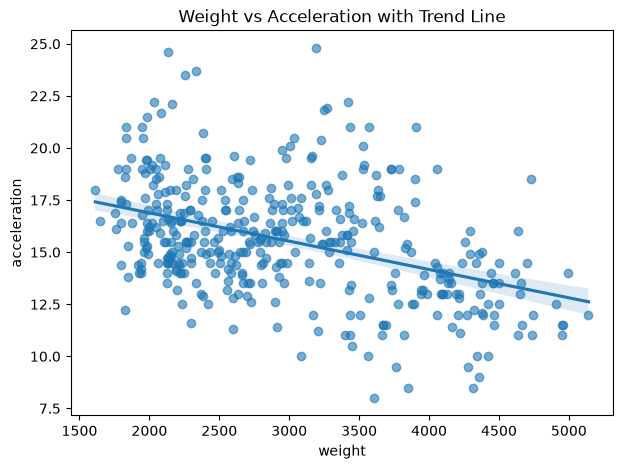

In [11]:
#추세선 추가 
plt.figure(figsize=(7, 5))
sns.regplot(data=df, x='weight', y='acceleration', scatter_kws={'alpha': 0.6})
plt.title('Weight vs Acceleration with Trend Line')
plt.show()

In [12]:
#상관계수를 숫자로 출력 
# -1 ~ +1 사이의 값으로 나오며, 0에 가까울수록 관계가 약합니다.
corr = df['weight'].corr(df['acceleration'])

print('상관계수(Correlation coefficient) : ', round(corr, 4) )
# 비교용 다른 조합
print('weight  <-> acceleration :', round(df['weight'].corr(df['acceleration']), 4))
print('horsepower <-> acceleration :', round(df['horsepower'].corr(df['acceleration']), 4))


상관계수(Correlation coefficient) :  -0.4175
weight  <-> acceleration : -0.4175
horsepower <-> acceleration : -0.6892


               mpg  cylinders  displacement  horsepower  weight  acceleration  \
mpg           1.00      -0.78         -0.80       -0.78   -0.83          0.42   
cylinders    -0.78       1.00          0.95        0.84    0.90         -0.51   
displacement -0.80       0.95          1.00        0.90    0.93         -0.54   
horsepower   -0.78       0.84          0.90        1.00    0.86         -0.69   
weight       -0.83       0.90          0.93        0.86    1.00         -0.42   
acceleration  0.42      -0.51         -0.54       -0.69   -0.42          1.00   
model_year    0.58      -0.35         -0.37       -0.42   -0.31          0.29   

              model_year  
mpg                 0.58  
cylinders          -0.35  
displacement       -0.37  
horsepower         -0.42  
weight             -0.31  
acceleration        0.29  
model_year          1.00  


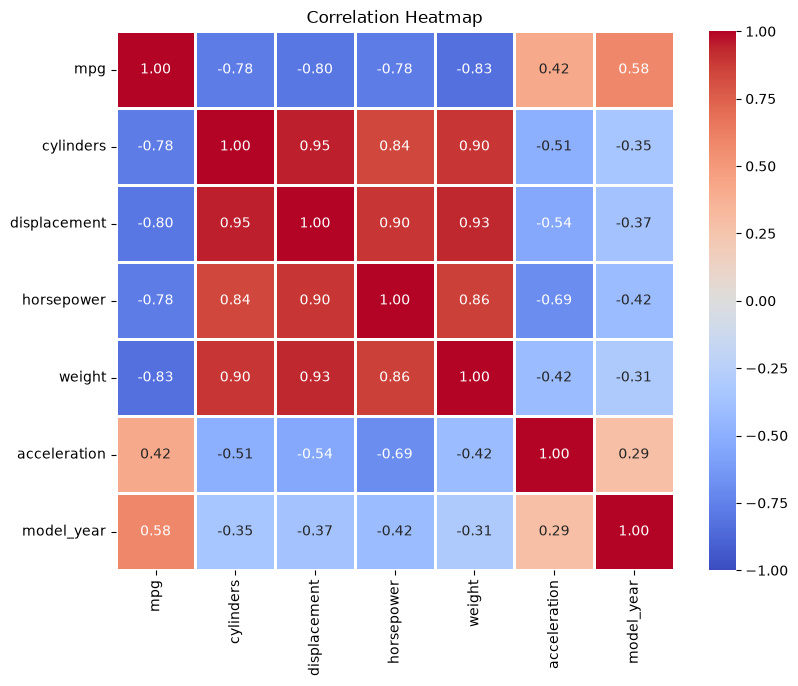

In [13]:
#행렬과 히트맵

# df = sns.load_dataset('mpg')

#   행렬
#   df.corr()는 모든 숫자형 변수 쌍의 상관계수를 한 번에 계산합니다.
#   numeric_only=True : 문자형 컬럼(origin, name)은 제외하고 계산
corr = df.corr(numeric_only=True)
print(corr.round(2))

#   히트맵
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=1, vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()


[[ True  True  True  True  True  True  True]
 [False  True  True  True  True  True  True]
 [False False  True  True  True  True  True]
 [False False False  True  True  True  True]
 [False False False False  True  True  True]
 [False False False False False  True  True]
 [False False False False False False  True]]


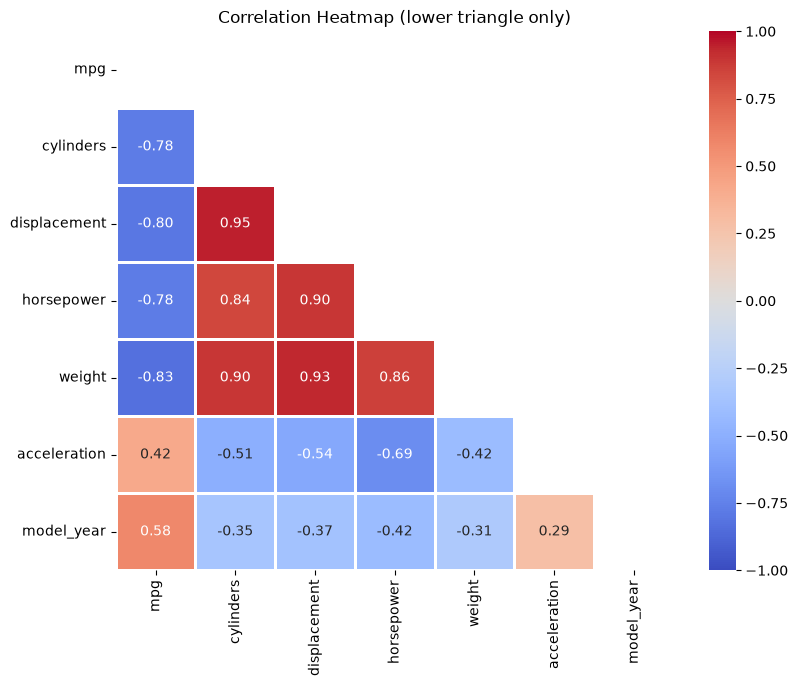

In [14]:
# 대각선을 기준으로 위아래가 똑같은 값이므로 중복을 삭제

# import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt

# df = sns.load_dataset('mpg')
# corr = df.corr(numeric_only=True)
#   np.triu() : 대각선 '포함' 위쪽을 True로 만듭니다. → 대각선(자기 자신, 항상 1.0)도 함께 숨겨집니다.
#   대각선을 남기고 싶다면 np.triu(..., k=1) 로 바꿔보세요.
mask = np.triu(np.ones_like(corr, dtype=bool))
print(mask)  # True인 칸이 히트맵에서 숨겨집니다

# mask=mask : True인 칸은 숨기고, False인 칸(아래 삼각형)만 표시
plt.figure(figsize=(9, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=1, vmin=-1, vmax=1)
plt.title('Correlation Heatmap (lower triangle only)')
plt.show()

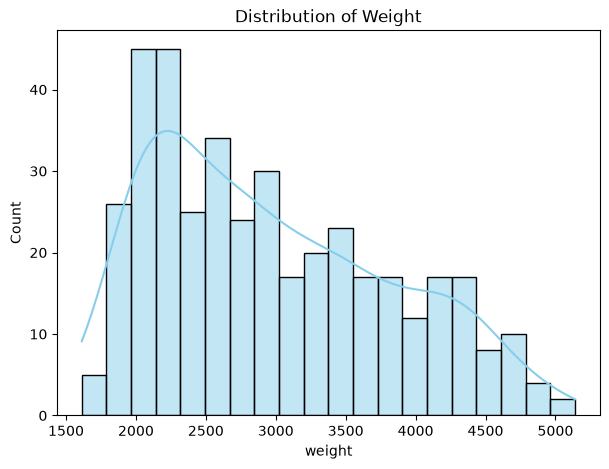

In [15]:
#분포 확인하기 - 값이 어디에 몰려있나
#히스토그램

# import seaborn as sns
# import matplotlib.pyplot as plt

# → 상관관계가 '변수 간의 관계'를 봤다면,
#   히스토그램은 '하나의 변수가 어떻게 생겼는지'를 봅니다.
#   값이 어디에 몰려있는지, 한쪽으로 쏠렸는지, 튀는 값은 없는지 확인합니다.
#   bins=20  : 데이터를 20개 구간으로 쪼개서 표시 (숫자를 바꿔가며 비교해 보세요)
#   kde=True : 막대 위에 부드러운 곡선을 함께 그려 전체 모양을 파악
plt.figure(figsize=(7, 5))
sns.histplot(df['weight'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Weight')
plt.show()

In [16]:
#분산 확인하기 - 데이터가 평균에서 얼마나 흩어져 있는지
import numpy as np

# A반 : 79, 80, 81점 (평균 80)
# → 다들 비슷한 점수. 평균 주변에 모여 있음.
data = np.array([79, 80, 81])
print(type(data))

# 왜 분산을 구하나요?
# → 평균만 보면 두 반 모두 80점으로 같습니다.
#   하지만 '다들 비슷한 80점'과 '들쑥날쑥한 80점'은 완전히 다른 상황입니다.
#   분산은 이 차이를 숫자로 표현해줍니다. (작으면 모여 있고, 크면 흩어져 있음)
variance = np.var(data)
print(f'A반 분산: {variance:.4f}')

## ----------------------------------------------------------
# [자주 하는 질문] numpy와 pandas의 분산 값이 다릅니다!
# ----------------------------------------------------------
# 같은 데이터인데 결과가 다릅니다. 버그가 아니라 기본 설정 차이입니다.
#   np.var()          → ddof=0 (모집단 분산). 가진 데이터가 전부라고 가정
#   pd.Series.var()   → ddof=1 (표본 분산).   가진 데이터가 일부 표본이라고 가정
# 앞에서 df.describe()로 본 std도 ddof=1 기준입니다.
print('numpy  분산(ddof=0):', round(np.var(data), 4))
print('pandas 분산(ddof=1):', round(pd.Series(data).var(), 4))
print('numpy에 ddof=1 지정:', round(np.var(data, ddof=1), 4))

<class 'numpy.ndarray'>
A반 분산: 0.6667
numpy  분산(ddof=0): 0.6667
pandas 분산(ddof=1): 1.0
numpy에 ddof=1 지정: 1.0


결측치 제거: 398행 → 392행 (6개 제외)


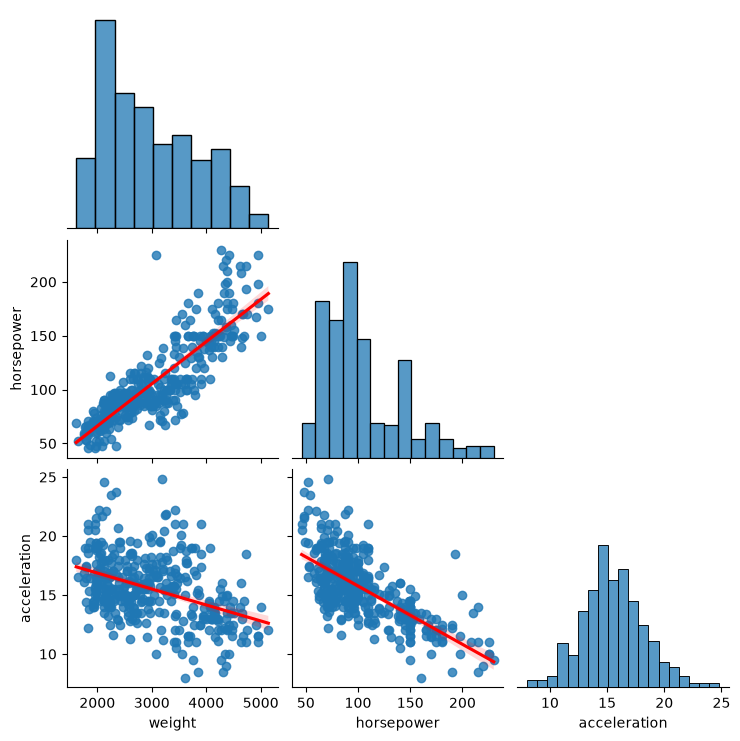

In [17]:
#pairplot
# 왜 결측치를 먼저 제거하나요?
# → pairplot은 결측치가 있는 행을 조용히 빼고 그립니다. 에러는 나지 않습니다.
#   하지만 '몇 개가 빠진 채로 그려졌는지' 모르는 상태로 해석하면 위험합니다.
#   그래서 직접 명시적으로 제거하고, 몇 개가 빠졌는지 확인하고 넘어갑니다.
before = len(df)
df = df.dropna(subset=['horsepower'])
print(f'결측치 제거: {before}행 → {len(df)}행 ({before - len(df)}개 제외)')

#   대각선   = 각 변수의 분포(히스토그램)
#   나머지   = 변수 쌍의 산점도 + 추세선
#   corner=True : 중복되는 윗부분 숨김 (히트맵에서 삼각형으로 자른 것과 같은 이유)
#   kind='reg'  : 산점도에 추세선(빨간 선) 추가
sns.pairplot(
    df[['weight', 'horsepower', 'acceleration']],
    corner=True,
    kind='reg',
    plot_kws={'line_kws': {'color': 'red'}}
)
plt.show()

## 싸이킷런

> **💡 reshape(-1, 1)이란?**
>
> 1차원 배열을 **세로로 긴 2차원 행렬**로 바꾸는 것입니다.
> ```
> [1, 2, 3, 4]  →  [[1],
>                    [2],
>                    [3],
>                    [4]]

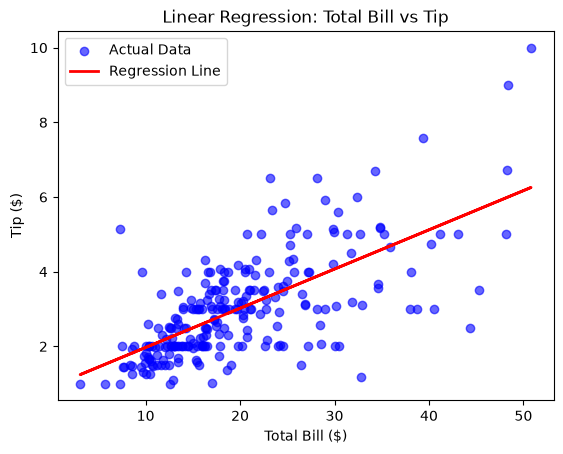

In [18]:
# 로컬에서는 설치 필요. 최초 1번 실행
#!pip install scikit-learn

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression



# ========== 1. 데이터 준비 ==========
tips = sns.load_dataset('tips')

# 왜 reshape(-1, 1)을 하나요?
# → 싸이킷런은 입력(X)을 반드시 "2차원 행렬"로 받습니다.
#   지금 X는 [3.07, 10.34, ...] 같은 1차원 배열인데,
#   이걸 [[3.07], [10.34], ...] 처럼 세로로 긴 2차원으로 바꿔야 합니다.
#   왜 2차원? → 나중에 피쳐(입력 변수)가 여러 개가 되면 열이 늘어나야 하니까요.
#   (ex: [[식사금액, 인원수], [식사금액, 인원수], ...] ← 피쳐 2개)
X = tips['total_bill'].values.reshape(-1, 1)
y = tips['tip'].values  # 정답(y)은 1차원 그대로 OK

# ========== 2. 모델 생성 및 학습 ==========
# 왜 두 줄로 나뉘어 있나요?
# → 1) 빈 모델을 만들고 (아직 아무것도 모르는 상태)
#   2) fit()으로 데이터를 먹여서 학습시킵니다.
#   fit() 안에서 오차(MSE)를 가장 작게 만드는 a, b를 한 번에 계산합니다.
#   (0-2챕터의 정규방정식과 같은 원리이며, 실제 구현은 수치적으로 더 안정적인 방식을 씁니다)
model = LinearRegression()
model.fit(X, y)

# ========== 3. 예측 ==========
# 왜 학습에 쓴 데이터로 다시 예측하나요?
# → 지금은 "모델이 제대로 만들어졌는지" 확인하기 위해서입니다.
#   나중에는 학습에 안 쓴 새로운 데이터로 예측해야 진짜 평가가 됩니다. (뒤에서 배움)
y_hat = model.predict(X)

# ========== 4. 시각화 ==========
plt.scatter(X, y, color='blue', alpha=0.6, label='Actual Data')
plt.plot(X, y_hat, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.title('Linear Regression: Total Bill vs Tip')
plt.legend()
plt.show()

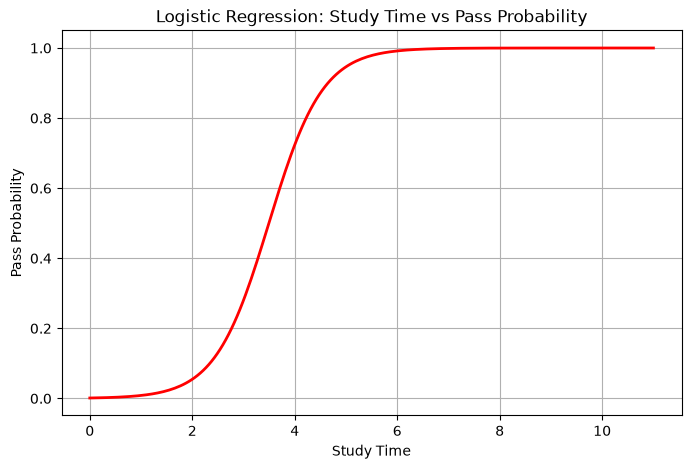

In [19]:
# 로지스틱 회귀

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# 공부 시간 (입력값) - 왜 reshape(-1, 1)? → 싸이킷런 입력은 항상 2차원!
X = np.array([1,2,3,4,5,6,2,3,4,5,6,7,1,2,3,4,5,6,7,8,2,3,4,5,6,7,8,9,10]).reshape(-1, 1)

# 합격 여부 (정답: 0=불합격, 1=합격)
y = np.array([0,0,0,1,1,1,0,0,1,1,1,1,0,0,0,1,1,1,1,1,0,0,1,1,1,1,1,1,1])

# 왜 LogisticRegression을 쓰나요? (LinearRegression이 아니라)
# → 이 문제는 "합격이냐 불합격이냐"를 맞추는 분류 문제입니다.
#   LinearRegression은 숫자를 예측하고, LogisticRegression은 확률을 예측합니다.
#   0-2챕터에서 배운 sigmoid(ax+b) 를 내부적으로 사용합니다.
model = LogisticRegression()
model.fit(X, y)

# 왜 linspace로 새 데이터를 만드나요?
# → 학습 데이터는 1,2,3...10 같은 듬성듬성한 정수입니다.
#   부드러운 S자 곡선을 그리려면 0~11 사이를 200등분한 촘촘한 값이 필요합니다.
X_new = np.linspace(0, 11, 200).reshape(-1, 1)

# 왜 predict가 아니라 predict_proba를 쓰나요?
# → predict()는 0 또는 1만 반환합니다. (합격/불합격)
#   predict_proba()는 [불합격확률, 합격확률]을 반환합니다. (예: [0.3, 0.7])
#   S자 곡선을 그리려면 확률값이 필요하니까 predict_proba()를 씁니다.
y_hat = model.predict_proba(X_new)
y_hat = y_hat[:, 1]  # 왜 [:, 1]? → [불합격, 합격] 중 합격확률(두번째 열)만 추출


plt.figure(figsize=(8, 5))
plt.plot(X_new, y_hat, color='red', linewidth=2)
plt.xlabel('Study Time')
plt.ylabel('Pass Probability')
plt.grid(True)
plt.title('Logistic Regression: Study Time vs Pass Probability')
plt.show()

[표준화 전] 평균 19.7859 / 표준편차 8.8842
[표준화 후] 평균 -0.0000 / 표준편차 1.0000
[표준화 후] 최솟값 -1.8815 / 최댓값 3.4921

→ 평균은 0, 표준편차는 1이 되었습니다.
→ 하지만 값의 범위는 0~1이 아닙니다. 음수도 나오고, 상한도 없습니다.


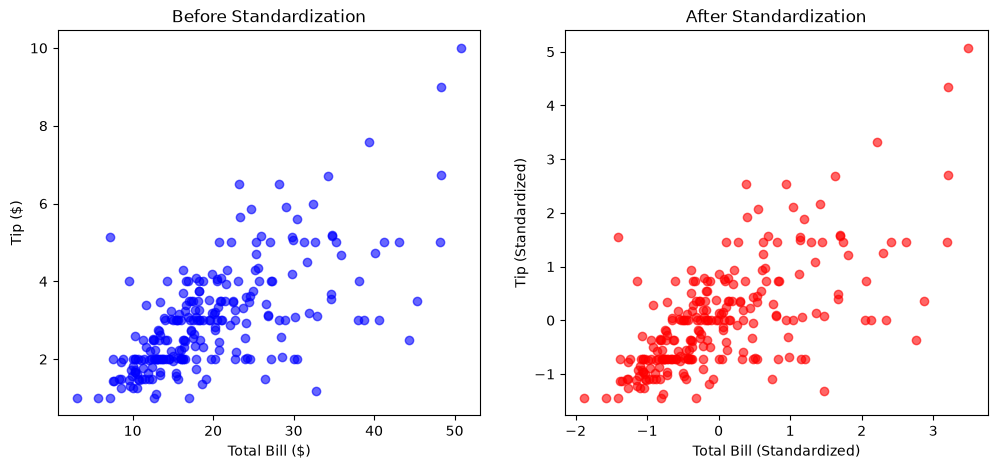

In [25]:
#표준화
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler #표준화는 StandardScaler 라는 클래스가 싸이킷런에 준비되어있습니다.

tips = sns.load_dataset('tips')

# tips.describe

X = tips['total_bill'].values.reshape(-1, 1)
y = tips['tip'].values.reshape(-1, 1)

# 왜 StandardScaler 객체를 X용, y용으로 각각 만드나요?
# → X(식사금액)와 y(팁금액)는 평균과 표준편차가 다릅니다.
#   각각의 기준을 따로 기억해야 하므로 scaler도 따로 만듭니다.
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# 왜 fit()과 transform()이 따로인가요?
# → fit()       : 데이터를 보고 평균과 표준편차를 '계산해서 기억'합니다. (아직 변환 안 함)
#   transform() : 기억해 둔 평균/표준편차로 실제 데이터를 '변환'합니다.
#   왜 분리하나? → 나중에 테스트 데이터를 변환할 때 '학습 데이터의 기준'을 그대로 써야 하기 때문입니다.
scaler_X.fit(X)
scaler_y.fit(y)
X_std = scaler_X.transform(X)
y_std = scaler_y.transform(y)

# 표준화가 실제로 무슨 일을 했는지 숫자로 확인해봅시다.
print(f'[표준화 전] 평균 {X.mean():.4f} / 표준편차 {X.std():.4f}')
print(f'[표준화 후] 평균 {X_std.mean():.4f} / 표준편차 {X_std.std():.4f}')
print(f'[표준화 후] 최솟값 {X_std.min():.4f} / 최댓값 {X_std.max():.4f}')
print()
print('→ 평균은 0, 표준편차는 1이 되었습니다.')
print('→ 하지만 값의 범위는 0~1이 아닙니다. 음수도 나오고, 상한도 없습니다.')

# 왜 차트를 나란히 비교하나요?
# → 표준화 전후로 데이터의 '모양(분포)'은 그대로이고 '축의 숫자'만 바뀐 것을 확인하기 위해서입니다.
#   모양이 바뀌면 안 됩니다. 데이터 특성은 유지하면서 스케일만 조정하는 것이 표준화입니다.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X, y, color='blue', alpha=0.6)
axes[0].set_title('Before Standardization')
axes[0].set_xlabel('Total Bill ($)')
axes[0].set_ylabel('Tip ($)')

axes[1].scatter(X_std, y_std, color='red', alpha=0.6)
axes[1].set_title('After Standardization')
axes[1].set_xlabel('Total Bill (Standardized)')
axes[1].set_ylabel('Tip (Standardized)')
plt.show()



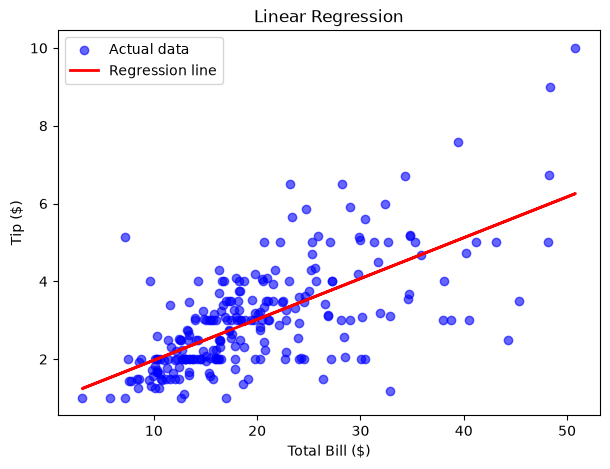

In [28]:
# 표준화된 데이터로 선형회귀
# import seaborn as sns
# import matplotlib.pyplot as plt
# from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# tips = sns.load_dataset('tips')

# X = tips['total_bill'].values.reshape(-1, 1)
# y = tips['tip'].values.reshape(-1, 1)

# # ========== 1단계: 표준화 (바로 앞에서 한 거) ==========
# scaler_X = StandardScaler()
# scaler_y = StandardScaler()

# scaler_X.fit(X)  # X의 평균, 표준편차 계산 (이 값은 나중에 테스트 데이터에도 그대로 재사용)
# scaler_y.fit(y)
# X_std = scaler_X.transform(X)
# y_std = scaler_y.transform(y)

# ========== 2단계: 모델 학습 (표준화된 데이터로!) ==========
model = LinearRegression()
model.fit(X_std, y_std)  # 왜 원본이 아니라 표준화 데이터로? → 학습이 더 정확해지니까!

# ========== 3단계: 예측 ==========
y_hat_std = model.predict(X_std)
# 왜 예측값도 표준화된 상태인가요?
# → 표준화된 데이터로 학습했으니, 예측값도 표준화된 스케일로 나옵니다.
#   예측 팁이 0.3, -0.5 이런 값이면 사람이 이해할 수 없죠.
#   그래서 원래 달러 단위로 되돌려야 합니다!

# ========== 4단계: 원본 스케일로 복원 (왜? 사람이 이해하려고) ==========
y_hat = scaler_y.inverse_transform(y_hat_std)  # 표준화 ↔ 원본 변환

# 시각화 (원본 단위로 그래야 의미있는 차트가 됨)
plt.figure(figsize=(7, 5))
plt.scatter(X, y, color='blue', alpha=0.6, label='Actual data')
plt.plot(X, y_hat, color='red', linewidth=2, label='Regression line')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.title('Linear Regression')
plt.legend()
plt.show()

In [29]:
#새로운 X를 넣어 Y를 예측해보자
# $50어치 식사한 손님의 팁을 예측해봅시다.
new_bill = [[50]]

# 왜 테스트 값도 표준화해야 하나요?
# → 모델이 '표준화된 세계'에서 학습했기 때문입니다.
#   모델 입장에서 50이라는 원본 숫자는 학습할 때 본 적이 없는 스케일입니다.
#   학습할 때와 같은 기준(같은 평균, 같은 표준편차)으로 변환해줘야 올바르게 예측합니다.
#   ★ 핵심: 학습 때 쓴 scaler_X를 그대로 재사용해야 합니다.
#          (새 scaler를 만들어 fit하면 기준이 달라져 예측이 어긋납니다)
new_bill_std = scaler_X.transform(new_bill)
print(f'입력값 $50 → 표준화 후: {new_bill_std[0][0]:.4f}')


# 예측 (표준화된 입력 → 표준화된 출력)
pred_tip_std = model.predict(new_bill_std)

# 왜 다시 inverse_transform을 하나요?
# → 모델이 내놓은 예측값은 표준화된 값입니다. 사람이 읽을 수 없습니다.
#   원래 달러 단위로 되돌려야 의미를 알 수 있습니다.
pred_tip = scaler_y.inverse_transform(pred_tip_std)

print(f'$50 식사한 손님의 예상 TIP : ${pred_tip[0][0]:.2f}')


입력값 $50 → 표준화 후: 3.4009
$50 식사한 손님의 예상 TIP : $6.17


In [34]:
# 모델 평가하기
# import seaborn as sns
# from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# tips = sns.load_dataset('tips')
# X = tips['total_bill'].values
# y = tips['tip'].values

print(f'원본 개수 : {X.size}개')

# 왜 random_state=42인가요?
# → 데이터를 "랜덤으로 섞어서" 나누는데,
#   random_state를 고정하면 실행할 때마다 같은 방식으로 나뉩니다.
#   이래야 결과를 재현할 수 있어요. (42가 아니라 아무 숫자나 OK)
#   test_size=0.2 -> 시험용이 20%이다.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f'\n[분할 후] Train 데이터 수 : {X_train.size}개 (80%)')
print(f'[분할 후] Test 데이터 수 : {X_test.size}개 (20%)')


원본 개수 : 244개

[분할 후] Train 데이터 수 : 195개 (80%)
[분할 후] Test 데이터 수 : 49개 (20%)


In [32]:
# 잠깐. 나중을 위해서 2개가 아니라 3개로 분리하자. 

# Train = 80%, Validation = 10%, Test = 10%
# → Train: 공부용 / Test: 최종 수능
#   Validation = 모의고사. 학습 도중에 중간 점검하는 용도입니다.
#   모의고사 결과를 보고 "학습률을 바꿀까? 학습을 멈출까?" 판단합니다.

import seaborn as sns
from sklearn.model_selection import train_test_split

tips = sns.load_dataset('tips')
X = tips['total_bill'].values
y = tips['tip'].values

print(f'원본 개수 : {X.size}개')

# 1차 분할 : Train(80%) vs 나머지(20%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

# 왜 2번 나누나요? (train_test_split은 2개로만 나눌 수 있어서!)
# 2차 분할 : 나머지(20%)를 다시 반반 → Validation(10%) + Test(10%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f'[분할 후] Train 데이터 수 : {X_train.size}개 (약 80%)')
print(f'[분할 후] Validation 데이터 수 : {X_val.size}개 (약 10%)')
print(f'[분할 후] Test 데이터 수 : {X_test.size}개 (약 10%)')

원본 개수 : 244개
[분할 후] Train 데이터 수 : 195개 (약 80%)
[분할 후] Validation 데이터 수 : 24개 (약 10%)
[분할 후] Test 데이터 수 : 25개 (약 10%)


In [35]:
##MSE와 R^2로 선형회귀 모델에서 평가
# MSE : 평균적으로 얼마나 틀렸는지 (0에 가까울수록 좋음)
# R²  : 데이터의 흐름을 얼마나 잘 설명하는지 (1에 가까울수록 좋음)
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

tips = sns.load_dataset('tips')
X = tips['total_bill'].values.reshape(-1, 1)
y = tips['tip'].values

# 왜 데이터를 먼저 나누고, 그 다음에 학습하나요?
# → 나누기 전에 학습하면 모델이 Test 데이터까지 이미 본 상태가 됩니다.
#   시험 문제를 미리 보고 공부한 것과 같습니다. (데이터 유출)
#   반드시 '데이터 분리 → Train으로만 학습 → Test로 평가' 순서를 지킵니다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train 데이터로만 학습 (Test 데이터는 건드리지 않습니다)
model = LinearRegression()
model.fit(X_train, y_train)


# 왜 Train 점수도 같이 구하나요?
# → 14장에서 배운 과적합/과소적합을 판단하려면 두 점수를 '비교'해야 하기 때문입니다.
#   Test 점수만 보면 그 숫자가 좋은지 나쁜지 판단할 기준이 없습니다.
train_mse = mean_squared_error(y_train, model.predict(X_train))
train_r2 = r2_score(y_train, model.predict(X_train))
test_mse = mean_squared_error(y_test, model.predict(X_test))
test_r2 = r2_score(y_test, model.predict(X_test))

print(f'[Train] MSE {train_mse:.4f} / R² {train_r2:.4f}')
print(f'[Test ] MSE {test_mse:.4f} / R² {test_r2:.4f}')



[Train] MSE 1.1561 / R² 0.4310
[Test ] MSE 0.5688 / R² 0.5449


In [37]:
## 로시스틱 회귀에서 Accuracy와 F1-Score,AUC 평가
## accuracy: 전체 중 맞춘 비율
## F1-score: 정밀도와 재현율의 조화 평균
## AUC: 0과 1을 얼마나 잘 구분하는지.
## 셋 다 1에 가까울수록 좋음
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

# 10장에서 쓴 것과 같은 데이터입니다. (공부 시간 → 합격 여부)
X = np.array([1,2,3,4,5,6,2,3,4,5,6,7,1,2,3,4,5,6,7,8,2,3,4,5,6,7,8,9,10]).reshape(-1, 1)
y = np.array([0,0,0,1,1,1,0,0,1,1,1,1,0,0,0,1,1,1,1,1,0,0,1,1,1,1,1,1,1])

# 왜 stratify=y 를 넣나요? (분류 문제에서는 사실상 필수)
# → 데이터가 29개뿐이라 그냥 무작위로 나누면,
#   운이 나쁘면 Test에 합격(1)만 들어가는 일이 생깁니다.
#   그러면 F1이나 AUC 계산이 아예 불가능하거나 이상한 값이 나옵니다.
#   stratify=y 는 원본의 합격/불합격 비율을 Train과 Test에 똑같이 유지해줍니다.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)
print(f'Train {len(y_train)}개 / Test {len(y_test)}개')
print(f'Test 정답 구성 → 불합격 {(y_test == 0).sum()}개, 합격 {(y_test == 1).sum()}개')
print()

# Train 데이터로 학습
model = LogisticRegression()
model.fit(X_train, y_train)

# 왜 predict와 predict_proba를 둘 다 쓰나요?
# → predict()       : 0 또는 1로 확정 판단 → Accuracy, F1 계산에 사용
#   predict_proba() : 확률값(0.0~1.0)    → AUC 계산에는 확률값이 필요
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]  # 합격 확률만 추출

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print(f'Accuracy : {acc:.4f}')
print(f'F1-score : {f1:.4f}')
print(f'AUC      : {auc:.4f}')

Train 20개 / Test 9개
Test 정답 구성 → 불합격 3개, 합격 6개

Accuracy : 1.0000
F1-score : 1.0000
AUC      : 1.0000
